# Milestone 02: Data preparation, EDA and hypotheses
**Who Pays More, and Who Can Least Afford It? Food Price Premiums, Deprivation and Abnormal Price Movements Across Selected Pakistani Urban Markets**

CS/SDP 312/314 Data Science for Social Good, Habib University, Fall 2026.

This notebook runs top to bottom from the raw files in the repository, with no network access. It calls the same
functions as `scripts/m02_eda.py` (package `pfp/`). Every statistic quoted in the manuscript is written by this code
to `reports/m02/m02_numbers.json`.

Sections follow the course sequence. Part A uses techniques taught in Units 02 to 07. Part B uses later-syllabus
methods in **exploratory** form only; they are labelled as such and nothing in Part B is confirmatory.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
from pfp import eda
from pfp.config import TRAIN_CUTOFF, BACKFILL_MANIFEST
from pfp.build import build_all
from pfp.external import parse_census_table1
eda.N.clear()
print("Training cutoff:", TRAIN_CUTOFF)

Training cutoff: 2026-09-24


## 1. Ingestion: parse every Appendix-A block and build the master dataset
`build_all()` parses all training-week workbooks (three stacked blocks, 17 cities, 51 items), runs the acceptance
assertions on each week, deduplicates byte-identical copies, merges the external sources and writes the master
dataset. Holdout weeks (after the cutoff) are skipped by file name before they are opened.

In [2]:
o = build_all(write=True)
m, city = o["master"], o["city"]
manifest = pd.read_csv(BACKFILL_MANIFEST)
weeks = eda.inventory(o); eda.backfill_summary(manifest); eda.external_summary(o)
print(f"master: {m.shape}, weeks {m.week_end.min().date()} to {m.week_end.max().date()} ({m.week_end.nunique()})")
print(json.dumps({k: eda.N[k] for k in ["panel", "validation", "files", "backfill"]}, indent=1))

master: (23409, 46), weeks 2025-05-15 to 2026-09-24 (27)
{
 "panel": {
  "rows": 23409,
  "cols": 46,
  "weeks": 27,
  "first_week": "2025-05-15",
  "last_week": "2026-09-24",
  "cities": 17,
  "items": 51,
  "food_items": 32,
  "consecutive_pairs": 15,
  "pairs_7d": 14,
  "pairs_6d": 1,
  "gap_min_nonconsec": 13,
  "gap_max": 77,
  "thursdays": 25,
  "wednesdays": 2,
  "structural_missing_rows": 83,
  "structural_missing_pct": 0.3546,
  "train_cutoff": "2026-09-24",
  "cities_by_province": {
   "Punjab": 8,
   "Sindh": 4,
   "KP": 2,
   "Balochistan": 2,
   "ICT": 1
  }
 },
 "validation": {
  "item_weeks_checked": 1377,
  "min_max_pass": 1377,
  "gm_pass": 1377,
  "gm_max_abs_rel_err_pct": 0.046,
  "am_median_abs_rel_err_pct": 0.4191,
  "md_median_abs_rel_err_pct": 1.0693
 },
 "files": {
  "kept": 27,
  "duplicates": 12,
  "raw_annex_files": 39
 },
 "backfill": {
  "thursdays_attempted": 73,
  "pages_requested": 197,
  "weeks_found": 12,
  "weeks_missing": 61,
  "train_found": 11,
  "

### Acceptance checks against PBS's own national columns
For every item-week, the minimum and maximum across the 17 parsed cities must equal PBS's National Average MIN and MAX,
and the geometric mean of the quoting cities' AVG must be within 0.1% of PBS's National Average AVG. The arithmetic
mean and the median do not reproduce PBS's figure, which identifies the geometric mean as PBS's reference price.

### Merged external sources
City table: Census 2023 population and four PSLM 2019-20 deprivation indicators (district totals), plus the
composite. Urban food CPI by month is used as a deflator only.

In [3]:
display(o["crosswalk"]); display(city.round(3)); o["cpi"]

,city,city_code,province,pslm_districts,census_units,pslm_rule,population_rule,notes
0,Islamabad,01,ICT,Islamabad,ISLAMABAD,single district,sum of census units (total and urban),Islamabad and Rawalpindi are one contiguous ma...
1,Rawalpindi,02,Punjab,Rawalpindi,RAWALPINDI,single district,sum of census units (total and urban),See Islamabad.
2,Gujranwala,03,Punjab,Gujranwala,GUJRANWALA,single district,sum of census units (total and urban),
3,Sialkot,04,Punjab,Sialkot,SIALKOT,single district,sum of census units (total and urban),
4,Lahore,05,Punjab,Lahore,LAHORE,single district,sum of census units (total and urban),District is 100% urban in Census 2023.
5,Faisalabad,06,Punjab,Faisalabad,FAISALABAD,single district,sum of census units (total and urban),
6,Sargodha,07,Punjab,Sargodha,SARGODHA,single district,sum of census units (total and urban),
7,Multan,08,Punjab,Multan,MULTAN,single district,sum of census units (total and urban),
8,Bahawalpur,09,Punjab,Bahawalpur,BAHAWALPUR,single district,sum of census units (total and urban),
9,Karachi,10,Sindh,Karachi Central; Karachi East; Karachi Malir; ...,KARACHI CENTRAL; KARACHI EAST; MALIR; KARACHI ...,population-weighted mean of 6 PSLM districts (...,sum of census units (total and urban),Seven census districts form one SPI market; PS...


,city,city_code,province,pop_total,pop_urban,fies_mod_sev_pct,fies_severe_pct,literacy10_total_pct,literacy10_urban_pct,out_of_school_total_pct,out_of_school_urban_pct,tap_water_total_pct,tap_water_urban_pct,pslm_rule,illiteracy10_pct,out_of_school_pct,no_tap_water_pct,illiteracy10_urban_pct,no_tap_water_urban_pct,fies_mod_sev_pct_mm,illiteracy10_pct_mm,out_of_school_pct_mm,no_tap_water_pct_mm,deprivation_composite,deprivation_composite_nowater,log_pop_urban,log_pop_total
0,Islamabad,01,ICT,2.3639e+06,1.1089e+06,7.930,2.03,85.000,86.000,10.000,11.000,25.690,24.370,single district,15.000,10.000,74.310,14.000,75.630,0.000,0.000,0.000,0.624,0.156,0.000,13.919,14.676
1,Rawalpindi,02,Punjab,6.1189e+06,4.2108e+06,9.410,1.88,82.000,85.000,10.000,11.000,22.840,32.410,single district,18.000,10.000,77.160,15.000,67.590,0.069,0.048,0.000,0.666,0.196,0.039,15.253,15.627
2,Gujranwala,03,Punjab,5.9598e+06,3.5940e+06,10.530,2.11,74.000,79.000,15.000,13.000,4.940,6.540,single district,26.000,15.000,95.060,21.000,93.460,0.122,0.175,0.100,0.928,0.331,0.132,15.095,15.601
3,Sialkot,04,Punjab,4.4994e+06,1.4820e+06,9.650,1.43,79.000,81.000,11.000,9.000,6.220,16.650,single district,21.000,11.000,93.780,19.000,83.350,0.081,0.095,0.020,0.909,0.276,0.065,14.209,15.319
4,Lahore,05,Punjab,1.3004e+07,1.3004e+07,17.960,2.61,77.000,77.000,16.000,16.000,23.290,23.290,single district,23.000,16.000,76.710,23.000,76.710,0.470,0.127,0.120,0.659,0.344,0.239,16.381,16.381
5,Faisalabad,06,Punjab,9.0758e+06,4.3930e+06,8.670,1.31,67.000,74.000,21.000,18.000,9.890,12.810,single district,33.000,21.000,90.110,26.000,87.190,0.035,0.286,0.220,0.855,0.349,0.180,15.296,16.021
6,Sargodha,07,Punjab,4.3344e+06,1.6096e+06,16.380,2.41,67.000,79.000,18.000,13.000,7.560,11.060,single district,33.000,18.000,92.440,21.000,88.940,0.396,0.286,0.160,0.889,0.433,0.281,14.291,15.282
7,Multan,08,Punjab,5.3623e+06,2.4999e+06,16.880,1.63,61.000,75.000,30.000,19.000,10.910,18.290,single district,39.000,30.000,89.090,25.000,81.710,0.420,0.381,0.400,0.840,0.510,0.400,14.732,15.495
8,Bahawalpur,09,Punjab,4.2850e+06,1.6193e+06,21.250,5.00,49.000,69.000,32.000,18.000,13.130,15.170,single district,51.000,32.000,86.870,31.000,84.830,0.624,0.571,0.440,0.808,0.611,0.545,14.298,15.271
9,Karachi,10,Sindh,2.0383e+07,1.8868e+07,9.604,0.65,76.155,76.746,25.739,25.267,67.064,67.298,population-weighted mean of 6 PSLM districts (...,23.845,25.739,32.936,23.254,32.702,0.079,0.140,0.315,0.018,0.138,0.178,16.753,16.830


,month,cpi_urban_food,cpi_source,cpi_ref
0,2024-07-01,276.10,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
1,2024-08-01,280.27,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
2,2024-09-01,276.17,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
3,2024-10-01,281.39,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
4,2024-11-01,279.93,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
5,2024-12-01,279.90,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
6,2025-01-01,278.37,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
7,2025-02-01,271.84,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
8,2025-03-01,277.04,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."
9,2025-04-01,271.43,CpI-Urban-Groupwise-Cumulative-Indices.pdf,"pdf page 28, row 'Food and non-alcoholic Bever..."


In [4]:
o["checks"].describe().loc[["mean", "min", "max"]]

,items_checked,min_max_pass,gm_pass,gm_max_abs_rel_err,am_median_abs_rel_err,md_median_abs_rel_err,structural_zero_rows
mean,51.0,51.0,51.0,1.6000e-04,0.0041,0.0102,3.0741
min,51.0,51.0,51.0,8.9198e-05,0.0025,0.0064,3.0000
max,51.0,51.0,51.0,4.6015e-04,0.0052,0.0137,4.0000


In [5]:
o["inventory"][["source_file", "week_end", "status", "duplicate_of"]]

,source_file,week_end,status,duplicate_of
0,data/raw/verification/pbs_annex_2025-10-30.xlsx,2025-10-30,kept,NaN
1,data/raw/verification/pbs_annex_2025-12-11.xlsx,2025-12-11,kept,NaN
2,data/raw/verification/pbs_annex_2025-12-24.xlsx,2025-12-24,kept,NaN
3,data/raw/verification/pbs_annex_2026-02-26.xlsx,2026-02-26,kept,NaN
4,data/raw/verification/pbs_annex_2026-03-11.xlsx,2026-03-11,kept,NaN
5,data/raw/verification/pbs_annex_2026-03-26.xlsx,2026-03-26,kept,NaN
6,data/raw/verification/pbs_annex_2026-04-02.xlsx,2026-04-02,kept,NaN
7,data/raw/verification/pbs_annex_2026-04-09.xlsx,2026-04-09,kept,NaN
8,data/raw/verification/pbs_annex_2026-05-21.xlsx,2026-05-21,kept,NaN
9,data/raw/verification/pbs_annex_2026-06-04.xlsx,2026-06-04,kept,NaN


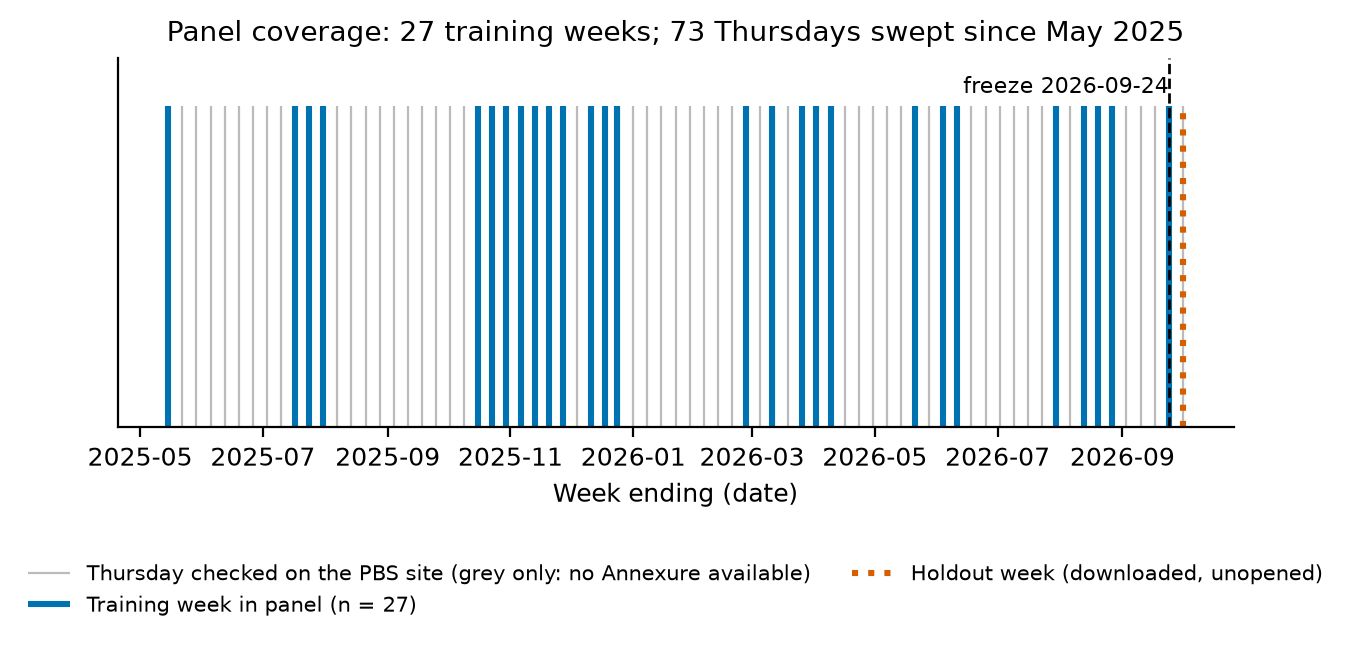

In [6]:
display(Image(eda.fig_coverage(o, manifest)))

## Part A. Techniques taught in Units 02 to 07

### Unit 02: Attribute types (codebook)
`city_code` and `item_id` are nominal even though they look like numbers. Price is ratio. `week_end` is interval.
`rel_price` is interval, so ratios of it mean nothing. Terciles are ordinal.

In [7]:
codebook = eda.codebook(m); codebook

,column,dtype,attribute_type,meaningful_operations,n_missing,pct_missing
0,week_end,datetime64[s],interval,differences in days; order; no true zero,0,0.00
1,year,int32,interval,"order, differences",0,0.00
2,month,int32,ordinal (cyclic),order within year; mode,0,0.00
3,iso_week,int64,ordinal (cyclic),order within year,0,0.00
4,city,str,nominal,"equality, counts, mode",0,0.00
5,city_code,str,nominal,equality only (stored as text),0,0.00
6,province,str,nominal,"equality, counts",0,0.00
7,item_id,int64,nominal,equality only (number is a PBS serial),0,0.00
8,item_label,str,nominal,equality,0,0.00
9,item_short,str,nominal,equality,0,0.00


### Unit 03: Tidy data and melting
In the raw sheet, city names are column headers spanning MIN/AVG/MAX, and three tables are stacked vertically. That
breaks all three tidy rules: a variable (city) is stored in headers, one observation (city-item-week) is spread over
three cells in a row, and one sheet holds three tables. The parser melts it to one row per city, item and week.

In [8]:
tidy = eda.tidy_demo(o, ROOT / o["inventory"].query("status == 'kept'").source_file.iloc[-1])
print("raw sheet (rows x cols):", tidy["raw_shape"], "-> tidy rows per week:", tidy["tidy_shape_per_week"][0])
m[m.week_end == m.week_end.max()][["week_end", "city", "city_code", "item_id", "item_short", "unit",
                                    "price_min", "price_avg", "price_max"]].head(6)

raw sheet (rows x cols): (179, 25) -> tidy rows per week: 867


,week_end,city,city_code,item_id,item_short,unit,price_min,price_avg,price_max
22542,2026-09-24,Islamabad,01,1,Wheat flour 20kg,20 Kg,2933.33,2993.14,3066.67
22543,2026-09-24,Islamabad,01,2,Rice basmati broken,1 Kg,260.00,274.83,290.00
22544,2026-09-24,Islamabad,01,3,Rice IRRI-6/9,1 Kg,160.00,178.64,200.00
22545,2026-09-24,Islamabad,01,4,Bread plain,Each,120.00,120.00,120.00
22546,2026-09-24,Islamabad,01,5,Beef with bone,1 Kg,1450.00,1491.13,1550.00
22547,2026-09-24,Islamabad,01,6,Mutton,1 Kg,2800.00,2849.49,2950.00


### Unit 03: Cleaning
Labels, implausible values and formats. We record what changed and delete nothing.

In [9]:
eda.cleaning_log(o)

,operation,rows_or_files,note
0,City labels with hyphen or line break repaired,0,Repair rule in parser; none needed in the 27 t...
1,Zero MIN/AVG/MAX triples set to missing,83,Structural non-quotes; PBS excludes them from ...
2,Week dates read from 'PRICES ON' text,27,All match the date in the file name
3,Item label wording changes mapped to first label,17,"Item 42 renamed in 2026-09-24 release, unit an..."
4,Duplicate workbooks dropped (identical sha256),12,Earlier repo copy kept; re-downloads byte-iden...
5,Rows deleted,0,"Nothing deleted; missing values are flagged, n..."


### Unit 03: Missing data
The options taught are: remove, impute from internal data, impute from external data, or fill with a constant. Below,
each of our three kinds of missingness is matched to a choice. The trade-off is statistical convenience against
selection bias. Imputing structural non-quotes would invent markets that PBS does not observe. Interpolating across
week gaps would invent price changes.

In [10]:
kinds, miss_cols = eda.missing_table(m); display(kinds); miss_cols

,kind,rows,options_considered,choice,reason
0,Structural non-quote (PBS printed 0/0/0),83.0,remove; impute from other cities (internal); c...,"set to missing, flag, do not impute",Imputing invents a market price PBS does not r...
1,Weekly change across a non-consecutive gap,10367.0,interpolate weeks; impute from CPI (external);...,leave missing,Interpolation would manufacture week-to-week c...
2,Weeks not retrieved from the PBS site,NaN,impute whole weeks; restrict to observed weeks,treat as a coverage gap,No source to impute from; stated as a limitati...


,n_missing,pct
price_min,83,0.3546
price_avg,83,0.3546
price_max,83,0.3546
log_price,83,0.3546
rel_price,83,0.3546
above_median,83,0.3546
above_median_prev,10450,44.6410
within_city_range_pct,83,0.3546
single_quote,83,0.3546
price_z_item_week,2903,12.4012


### Unit 03: Integration (stacking, augmenting, merging)
Each join's key and cardinality; the row count is asserted unchanged after every merge (see `pfp/build.py`).

In [11]:
eda.integration_table(o)

,operation,source,key,cardinality,rows_after
0,stack,3 Appendix-A blocks per workbook,same 51 item rows,rows: 7+7+3 cities x 51 = 867 per week,867
1,stack,27 weekly workbooks,week_end,867 x 27,23409
2,merge,item_mapping.csv,item_id,many-to-one (51 items),23409
3,merge,city table (Census 2023 + PSLM 2019-20),city,many-to-one (17 cities),23409
4,merge,urban food CPI,calendar month of week_end,many-to-one (months),23409


### Unit 04: Aggregation and change of scale
Moving from city to province to the national figure removes variability, and that removed variability is exactly
what this project studies. Moving from week to month barely changes cross-city dispersion because relative prices
are persistent.

,level,sd_rel_price
0,city x item x week,0.1299
1,city x item x month,0.1303
2,city x item (mean over weeks),0.1147
3,province x item (mean of cities),0.1083
4,national (reference),0.0000


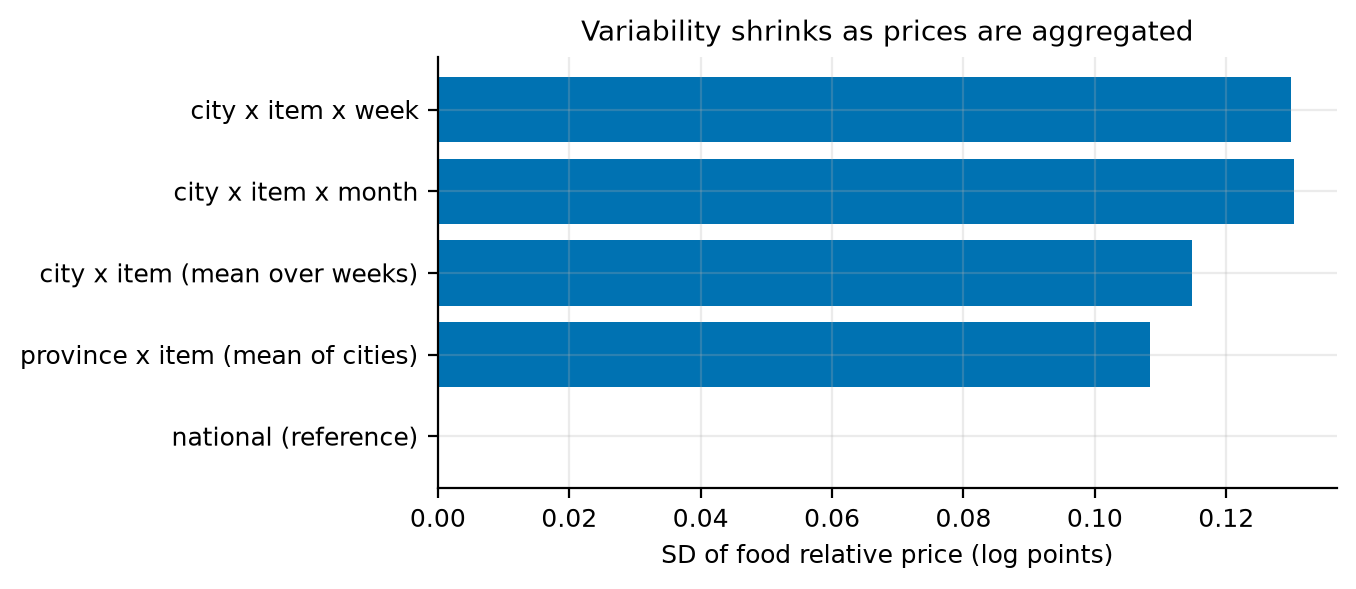

In [12]:
agg = eda.aggregation(m); display(agg); display(Image(eda.fig_aggregation(agg)))

### Unit 04: Splitting `week_end` into year, month and ISO week

In [13]:
eda.splitting(m).head(8)

,week_end,year,month,iso_week
0,2025-05-15,2025,5,20
867,2025-07-17,2025,7,29
1734,2025-07-24,2025,7,30
2601,2025-07-31,2025,7,31
3468,2025-10-16,2025,10,42
4335,2025-10-23,2025,10,43
5202,2025-10-30,2025,10,44
6069,2025-11-06,2025,11,45


### Unit 04: Sampling and the bootstrap
The 17 SPI cities are a **purposive** sample chosen by PBS, not a random one, so nothing here generalises to towns or
rural markets. Inside the panel, we resample items with replacement to put an interval on each city's median premium.

In [14]:
prem = eda.city_premiums(m); boot = eda.bootstrap_median(m); boot

,city,median,boot_lo,boot_hi,excludes_zero
0,Bahawalpur,-0.0248,-0.0737,0.0004,False
1,Bannu,-0.0467,-0.0978,-0.0127,True
2,Faisalabad,-0.0014,-0.0111,0.0024,False
3,Gujranwala,-0.0072,-0.0622,0.0031,False
4,Hyderabad,-0.0010,-0.0179,0.0065,False
5,Islamabad,0.1190,0.0433,0.1464,True
6,Karachi,0.0260,0.0161,0.0745,True
7,Khuzdar,0.0229,-0.0061,0.0529,False
8,Lahore,0.0004,-0.0245,0.0061,False
9,Larkana,-0.0016,-0.0646,0.0127,False


### Unit 04: Feature subset selection
**Redundant:** log MIN, AVG and MAX are almost perfectly correlated, so we keep AVG plus the within-city range.
**Irrelevant:** provenance columns. **Ranking H3 candidates:** we use the slide's mean-and-variance test,
|mean A - mean B| / SE(A - B), between rows labelled abnormal and normal next week. Thresholds are fitted on training
weeks only.

In [15]:
labelled, thresholds = eda.abnormal_labels(m)
print(json.dumps(eda.N["h3"], indent=1))
eda.feature_selection(m, labelled)

{
 "items_p90_zero": 13,
 "items_too_few_changes": 4,
 "base_rate_contract": 0.0775,
 "base_rate_refined": 0.0289,
 "labelled_rows_contract": 8115,
 "labelled_rows_refined": 7095
}


,feature,mean_abnormal,mean_normal,n_abnormal,n_normal,score
0,is_perishable,0.6244,0.3885,205,6890,6.8541
1,price_changed,0.5873,0.2854,126,4131,6.7703
2,abs_dlog,0.0746,0.0234,126,4131,4.2539
3,log_pop_urban,14.0562,14.3721,205,6890,3.0695
4,deprivation_composite,0.4671,0.4263,205,6890,2.8838
5,abs_dlog_lag1,0.0823,0.0262,61,1831,2.6799
6,abs_rel_price,0.1052,0.0861,205,6890,2.4341
7,rel_price,-0.0065,0.0002,205,6890,0.6142
8,single_quote,0.4732,0.4701,205,6890,0.0865
9,within_city_range_pct,6.8147,6.8320,205,6890,0.0215


### Unit 04: Discretisation
Karachi's population skews the distribution, so equal-width bins put 15 of the 17 cities in the lowest bin. We
therefore use equal-frequency terciles for the contingency tables and the H4 strata.

In [16]:
disc = eda.discretisation(city); cityx = eda.add_terciles(city, prem); disc

,variable,method,low,mid,high
0,pop_urban,equal-width,15,0,2
1,pop_urban,equal-frequency (terciles),6,5,6
2,deprivation_composite,equal-width,9,6,2
3,deprivation_composite,equal-frequency (terciles),6,5,6


### Unit 04: Normalisation
We use min-max scaling for the deprivation indicators (in `city_table`, columns `*_mm`) and z-scores for prices within
each item and week (`price_z_item_week`). Decimal scaling would divide wheat flour by 10^4 but the salt packet by
10^2, so it does not make items comparable, and we do not use it. Scaling matters for the distance-based methods in
Part B (clustering, nearest neighbours, PCA), which would otherwise give the most weight to the largest-valued
features. All constants are fitted on the training panel only.

In [17]:
display(eda.normalisation_demo(m, city)); city[["city"] + [c for c in city.columns if c.endswith("_mm")] + ["deprivation_composite"]].round(3)

,city,price_avg,price_z_item_week
22542,Islamabad,2993.14,1.0654
22593,Rawalpindi,2737.22,0.1251
22644,Gujranwala,2583.72,-0.4388
22695,Sialkot,2583.72,-0.4388
22746,Lahore,2218.86,-1.7793


,city,fies_mod_sev_pct_mm,illiteracy10_pct_mm,out_of_school_pct_mm,no_tap_water_pct_mm,deprivation_composite
0,Islamabad,0.000,0.000,0.000,0.624,0.156
1,Rawalpindi,0.069,0.048,0.000,0.666,0.196
2,Gujranwala,0.122,0.175,0.100,0.928,0.331
3,Sialkot,0.081,0.095,0.020,0.909,0.276
4,Lahore,0.470,0.127,0.120,0.659,0.344
5,Faisalabad,0.035,0.286,0.220,0.855,0.349
6,Sargodha,0.396,0.286,0.160,0.889,0.433
7,Multan,0.420,0.381,0.400,0.840,0.510
8,Bahawalpur,0.624,0.571,0.440,0.808,0.611
9,Karachi,0.079,0.140,0.315,0.018,0.138


### Unit 04: Encoding
We use 0/1 dummy columns for province and item category. Cities use sum-to-zero (deviation) coding, so each city's
coefficient is its premium relative to the average city.

In [18]:
display(eda.encoding_demo(m)); eda.sum_to_zero_matrix(eda.city_order(m)).iloc[[0, 1, 15, 16], :4]

,city,province,item_short,item_category,prov_ICT,prov_Sindh,prov_KP,prov_Balochistan,cat_perishable,cat_branded_packaged,cat_prepared_food
0,Islamabad,ICT,Beef with bone,perishable,1,0,0,0,1,0,0
1,Lahore,Punjab,Beef with bone,perishable,0,0,0,0,1,0,0
2,Karachi,Sindh,Beef with bone,perishable,0,1,0,0,1,0,0
3,Peshawar,KP,Beef with bone,perishable,0,0,1,0,1,0,0
4,Quetta,Balochistan,Beef with bone,perishable,0,0,0,1,1,0,0
5,Islamabad,ICT,Cooking oil 5L tin (brand),branded_packaged,1,0,0,0,0,1,0
6,Islamabad,ICT,Cooked daal (hotel plate),prepared_food,1,0,0,0,0,0,1


,c_Islamabad,c_Rawalpindi,c_Gujranwala,c_Sialkot
Islamabad,1.0,0.0,0.0,0.0
Rawalpindi,0.0,1.0,0.0,0.0
Quetta,0.0,0.0,0.0,0.0
Khuzdar,-1.0,-1.0,-1.0,-1.0


In [19]:
# The model-ready food table written by build_all(): provenance dropped, strings expanded to 0/1 dummies.
mr = pd.read_parquet(ROOT / "data/processed/m02/model_ready_food.parquet")
print(mr.shape); print([c for c in mr.columns if c.startswith(("prov_", "cat_"))])
mr.filter(regex="^(city|province|item_category|prov_|cat_)").drop_duplicates(["city", "item_category"]).head(6)

(14607, 46)
['prov_ICT', 'prov_Sindh', 'prov_KP', 'prov_Balochistan', 'cat_perishable', 'cat_branded_packaged', 'cat_prepared_food', 'cat_administered_utility', 'cat_other_nonfood']


,city,city_code,province,item_category,prov_ICT,prov_Sindh,prov_KP,prov_Balochistan,cat_perishable,cat_branded_packaged,cat_prepared_food,cat_administered_utility,cat_other_nonfood
0,Islamabad,01,ICT,storable_staple,1,0,0,0,0,0,0,0,0
3,Islamabad,01,ICT,prepared_food,1,0,0,0,0,0,1,0,0
4,Islamabad,01,ICT,perishable,1,0,0,0,1,0,0,0,0
9,Islamabad,01,ICT,branded_packaged,1,0,0,0,0,1,0,0,0
32,Rawalpindi,02,Punjab,storable_staple,0,0,0,0,0,0,0,0,0
35,Rawalpindi,02,Punjab,prepared_food,0,0,0,0,0,0,1,0,0


### Unit 05: Central tendency, including the geometric mean
Mean, median and mode for four items in the latest week. The mode is only meaningful where prices cluster on round
figures. PBS's national average is the **geometric** mean of the city averages (validated above), and we use it as
the reference price.

In [20]:
eda.central_tendency(m)

,item,unit,arithmetic_mean,geometric_mean,median,mode_rounded,n_modes
0,Wheat flour 20kg,20 Kg,2703.1612,2689.6058,2800.0,NaN,3
1,Chicken broiler (live),1 Kg,341.3212,340.6283,340.0,NaN,17
2,Tomatoes,1 Kg,155.7394,152.3353,150.0,150.0,1
3,Sugar refined,1 Kg,145.1088,145.0468,145.5,NaN,2


### Unit 05: Variation (range, IQR, variance, SD, coefficient of variation)
CV is the slide's measure for comparing spread across variables on different scales (PKR per kg, per dozen, per plate),
so it carries the cross-item dispersion analysis.

In [21]:
item = eda.variation_by_item(m); item.sort_values("mean_cv", ascending=False).head(12)

,item_id,item_short,is_food,item_category,mean_cv,mean_range,mean_iqr,mean_sd,mean_price,volatility,share_unchanged,share_single_quote
34,35,Shirting,0,other_nonfood,0.2930,631.7704,190.4889,159.8613,546.2117,0.0184,0.9725,0.2135
43,44,Energy saver bulb (brand),0,other_nonfood,0.2898,319.8593,224.0741,119.7864,413.4122,0.0204,0.9765,0.8039
15,16,Bananas,1,perishable,0.2694,163.0396,50.0030,46.1435,170.2332,0.0558,0.5804,0.2745
22,23,Tomatoes,1,perishable,0.2451,106.6370,41.9459,30.9798,138.4339,0.3172,0.1255,0.3268
20,21,Potatoes,1,perishable,0.2374,48.0859,18.0681,13.8781,62.3264,0.0807,0.5373,0.2636
42,43,Firewood,0,other_nonfood,0.2139,1165.2678,397.5089,314.0696,1471.8095,0.0220,0.9098,0.2985
36,37,Georgette,0,other_nonfood,0.2078,202.4478,110.3422,65.8476,316.5718,0.0117,0.9804,0.3704
1,2,Rice basmati broken,1,storable_staple,0.1916,143.6807,56.3230,41.8724,218.4536,0.0074,0.9490,0.2397
21,22,Onions,1,perishable,0.1837,69.2037,22.5059,19.2031,108.5454,0.1679,0.2588,0.3007
30,31,Cooked daal (hotel plate),1,prepared_food,0.1803,118.0667,38.0426,31.0439,172.4154,0.0097,0.9882,0.3268


In [22]:
eda.summary_table(m, city)

,variable,n,mean,median,sd,iqr,skew,min,max
0,"price_z_item_week (food; z-score, unitless)",14539,-7.8439e-16,-4.3477e-02,0.9700,1.2265,0.1893,-3.8650,3.7947
1,rel_price (food; log points),14607,-1.1492e-17,2.2204e-16,0.1299,0.1101,-0.1443,-1.2391,0.7081
2,"dlog_price (food; log points, consecutive weeks)",8115,-2.7181e-03,0.0000e+00,0.0718,0.0000,-1.3000,-0.9808,0.7087
3,within_city_range_pct (food; %),14607,6.8117e+00,1.3954e+00,11.6652,9.3844,3.5489,0.0000,152.8585
4,"single_quote (food; 1 if MIN = MAX, else 0)",14607,4.8607e-01,0.0000e+00,0.4998,1.0000,0.0557,0.0000,1.0000
5,fies_mod_sev_pct (17 cities; %),17,1.5314e+01,1.6380e+01,5.9261,8.3100,0.6466,7.9300,29.2600
6,illiteracy10_pct (17 cities; %),17,3.5756e+01,3.4000e+01,15.2617,20.1548,1.0803,15.0000,78.0000
7,out_of_school_pct (17 cities; %),17,2.8573e+01,2.5739e+01,15.4950,19.0000,0.6268,10.0000,60.0000
8,no_tap_water_pct (17 cities; %),17,7.6782e+01,8.1740e+01,20.6673,18.1300,-1.1212,31.6800,100.0000
9,deprivation_composite (17 cities; 0-1),17,4.2681e-01,3.4891e-01,0.2169,0.2609,0.8404,0.1380,0.9743


### Unit 05: Resistant and non-resistant statistics
We compare the mean premium with the median premium for each city. Where they diverge, a few items drive the mean,
and the median is the more resistant summary.

In [23]:
prem[["city", "pct_mean", "pct_median", "n_items"]].assign(gap=lambda d: d.pct_mean - d.pct_median).sort_values("gap")

,city,pct_mean,pct_median,n_items,gap
14,Larkana,-4.9228,-0.1641,32,-4.7587
15,Sukkur,-7.1148,-4.0520,32,-3.0628
16,Bannu,-7.3579,-4.5654,32,-2.7925
11,Sialkot,-2.6851,-0.2033,31,-2.4817
10,Hyderabad,-1.9266,-0.1039,32,-1.8227
13,Bahawalpur,-3.7808,-2.4509,32,-1.3299
9,Faisalabad,-1.4464,-0.1418,32,-1.3047
12,Sargodha,-3.6198,-2.6307,32,-0.9892
7,Lahore,-0.6797,0.0390,31,-0.7187
8,Gujranwala,-1.3118,-0.7194,31,-0.5924


### Unit 05: Outlier identification (quartile and mean/SD methods, mild and regular tiers)
On weekly log changes the IQR is 0, because most prices do not change. The quartile fences then collapse to zero and
flag every change; this is the masking and degenerate-fence problem. The SD method is inflated by the large moves it
is meant to find. We check the extremes against PBS's own national MIN and MAX columns and keep them flagged, because
large moves are what H3 studies.

In [24]:
display(eda.outliers(m)); eda.extreme_check(m, o["national"])

,variable,n,Q1,Q3,IQR,mean,sd,iqr_mild_1.5,iqr_regular_3,sd_mild_2,sd_regular_3
0,"rel_price, all 51 items",23326,-0.0374,0.0464,0.0838,1.1651e-17,0.1328,3649,1251,1598,434
1,"weekly log change, all items",12959,0.0000,0.0000,0.0000,7.5917e-04,0.0620,2502,2502,493,296


,week_end,city,item_id,item_short,price_avg,price_min,price_max,rel_price,source_file,nat_min,nat_max,nat_avg,equals_pbs_national_min_or_max
0,2025-05-15,Larkana,23,Tomatoes,13.10,10.0,15.0,-1.2391,data/raw/verification/final_scope/Annex_15.05....,10.0,90.0,45.23,True
1,2026-09-24,Quetta,35,Shirting,239.86,230.0,250.0,-0.8203,data/raw/pbs_backfill/pbs_annex_2026-09-24.xlsx,230.0,900.0,544.75,True
2,2026-08-27,Quetta,35,Shirting,239.86,230.0,250.0,-0.8203,data/raw/verification/pbs_annex_2026-08-27.xlsx,230.0,900.0,544.75,True
3,2026-08-20,Quetta,35,Shirting,239.86,230.0,250.0,-0.8203,data/raw/verification/pbs_annex_2026-08-20.xlsx,230.0,900.0,544.75,True
4,2026-07-30,Quetta,35,Shirting,239.86,230.0,250.0,-0.8201,data/raw/verification/pbs_annex_2026-07-30.xlsx,230.0,900.0,544.67,True
5,2026-08-13,Quetta,35,Shirting,239.86,230.0,250.0,-0.8201,data/raw/verification/pbs_annex_2026-08-13.xlsx,230.0,900.0,544.67,True
6,2025-05-15,Sukkur,23,Tomatoes,20.00,20.0,20.0,-0.8160,data/raw/verification/final_scope/Annex_15.05....,10.0,90.0,45.23,False
7,2025-12-18,Quetta,35,Shirting,229.85,220.0,240.0,-0.8065,data/raw/verification/final_scope/Annex_18.12....,220.0,900.0,514.90,True


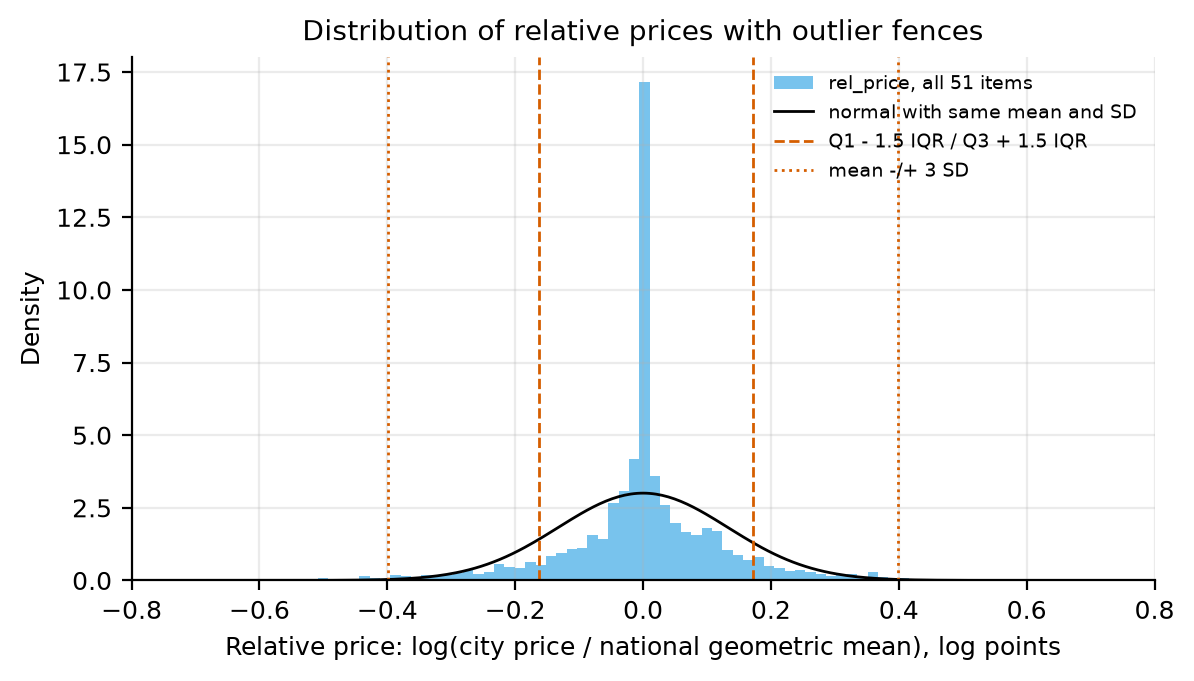

In [25]:
display(Image(eda.fig_relprice_hist(m)))

### Unit 05: Histograms, bar charts and box plots

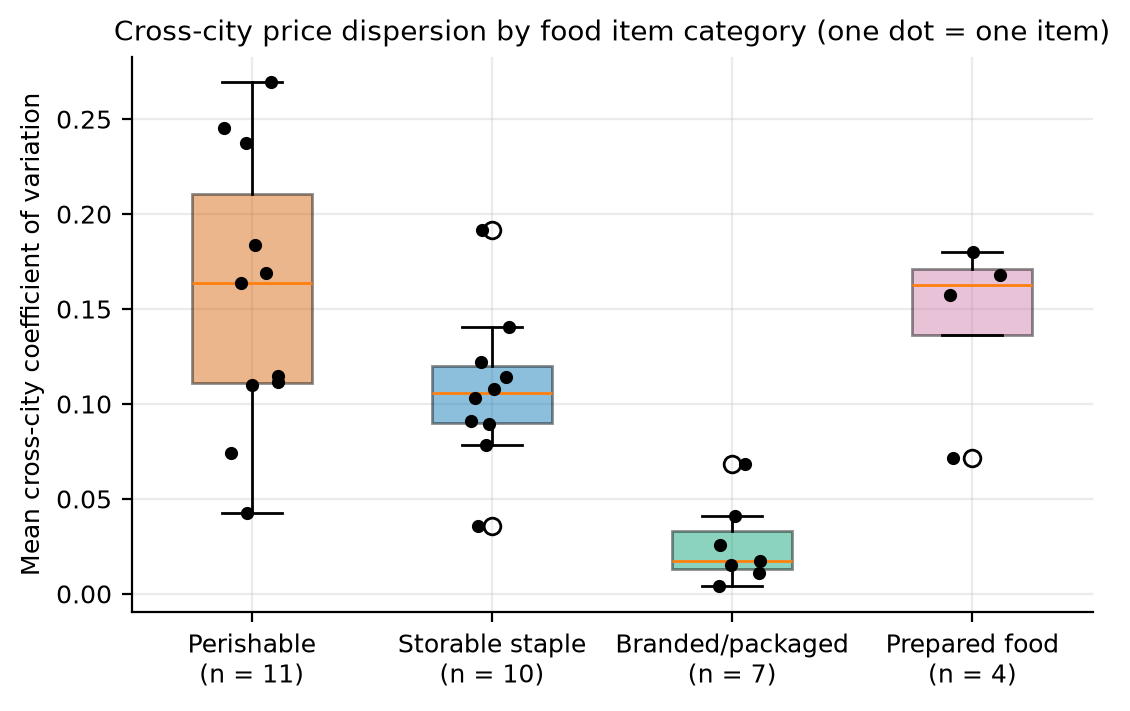

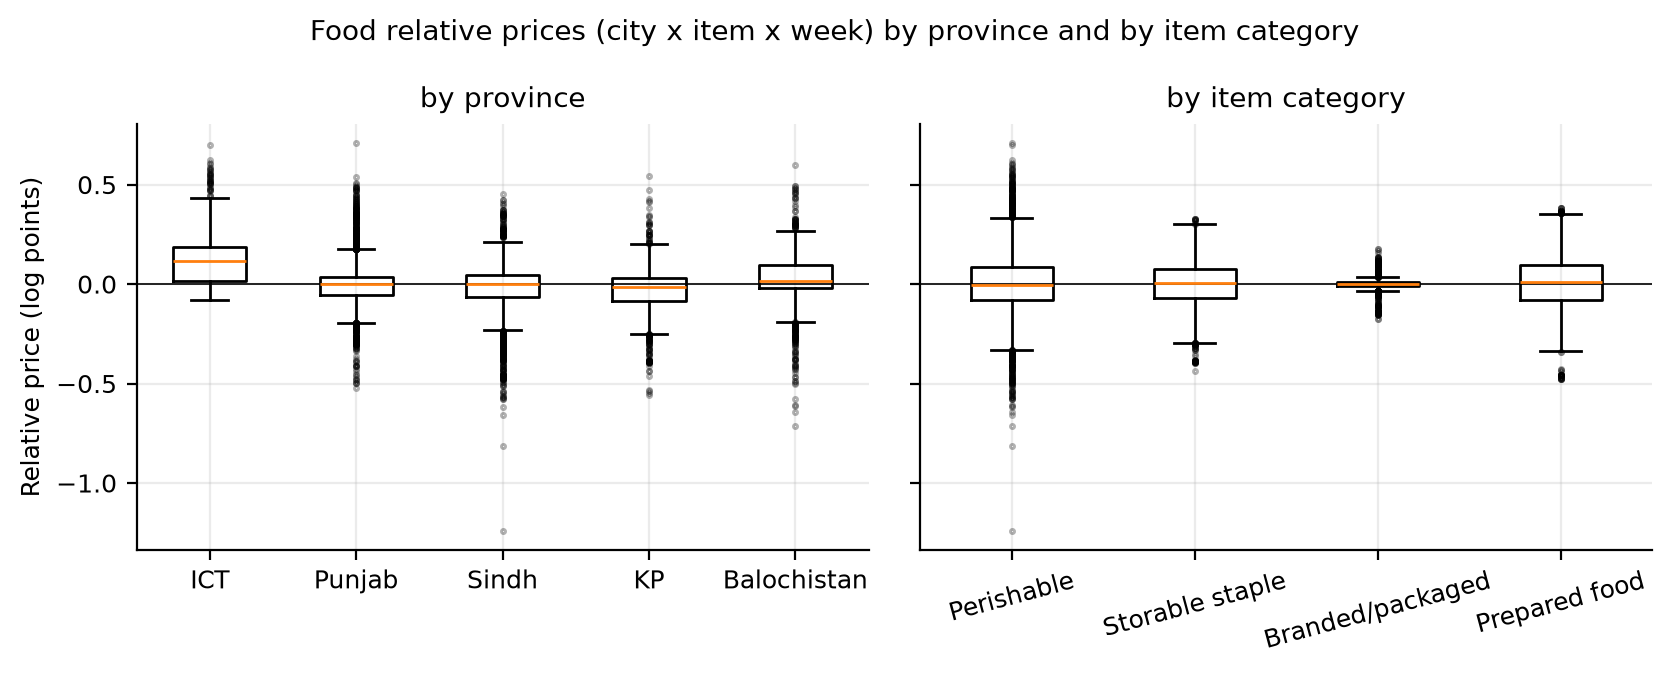

In [26]:
display(Image(eda.fig_dispersion(item))); display(Image(eda.fig_box_province_category(m)))

### Unit 05: Scatter plots and the Anscombe lesson
We plot before computing any coefficient. With n = 17, one city can make or break a correlation, so we also report
leave-one-out ranges.

,deprivation_measure,n,pearson_r,pearson_p,spearman_rho,spearman_p,loo_pearson_min,loo_pearson_max,loo_spearman_min,loo_spearman_max,loo_most_influential
0,deprivation_composite,17,-0.4941,0.0438,-0.5588,0.0197,-0.7297,-0.3968,-0.7206,-0.4765,Khuzdar
1,fies_mod_sev_pct,17,-0.3353,0.1883,-0.3211,0.2089,-0.4914,-0.1848,-0.4559,-0.1853,Khuzdar
2,deprivation_composite_nowater,17,-0.4430,0.0749,-0.5000,0.0410,-0.6643,-0.3083,-0.6588,-0.4000,Khuzdar


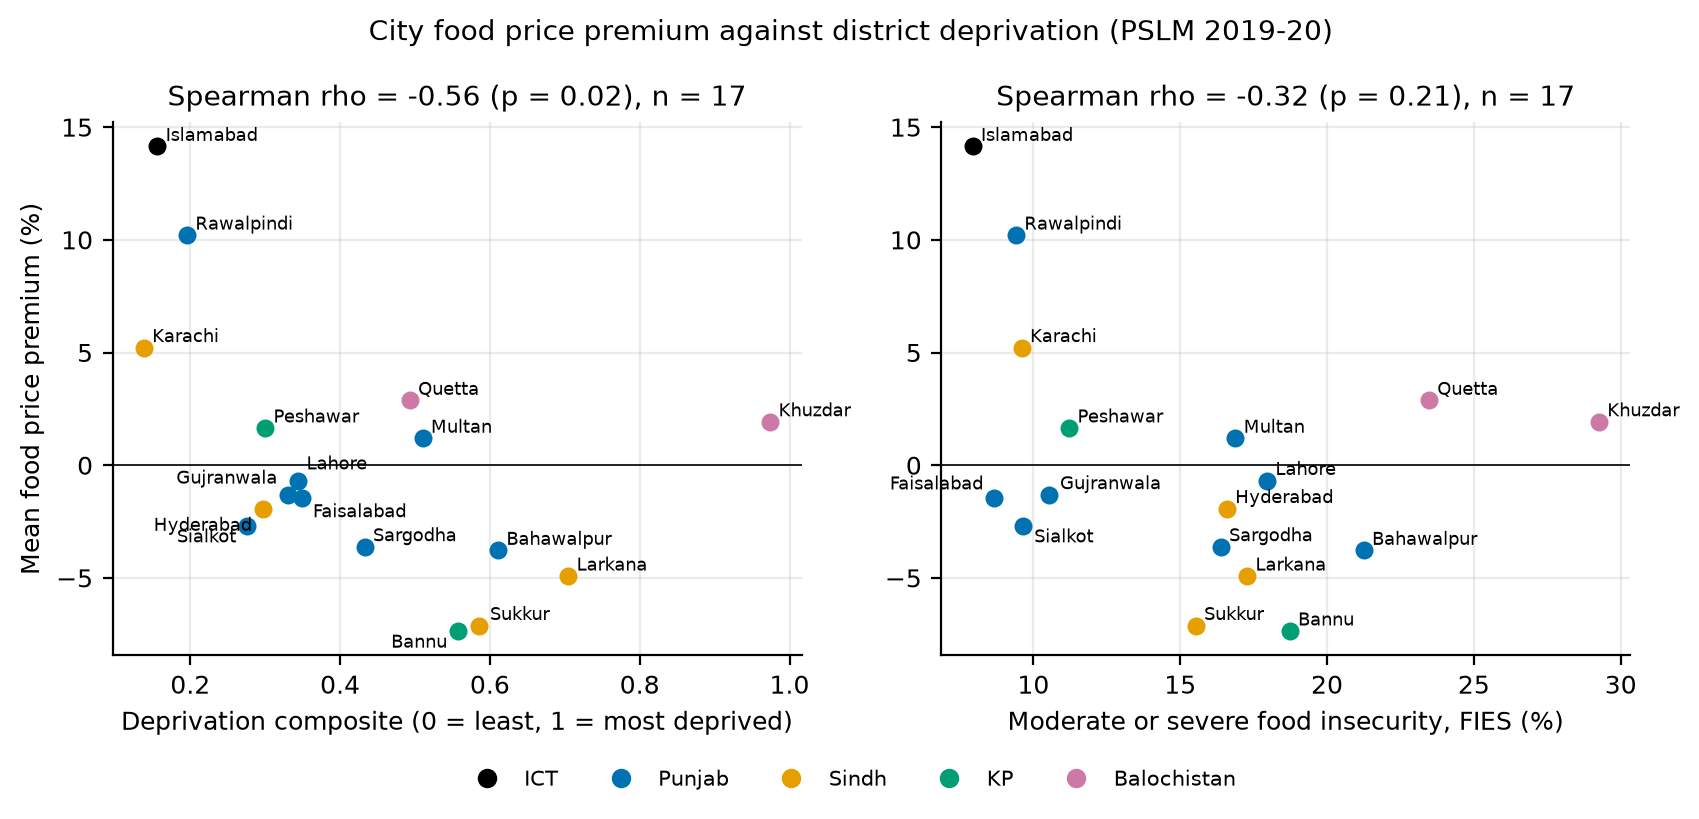

In [27]:
h5 = eda.premium_vs_deprivation(cityx); display(h5); display(Image(eda.fig_premium_deprivation(cityx, h5)))

### Unit 05: Covariance and correlation (Pearson and Spearman, city level, n = 17)

,premium,deprivation_composite,fies_mod_sev_pct,illiteracy10_pct,out_of_school_pct,no_tap_water_pct,log_pop_urban,single_quote_share
premium,0.0031,-0.0060,-0.1103,-0.3739,-0.3923,-0.3312,0.0287,-0.0096
deprivation_composite,-0.0060,0.0470,1.0881,3.0546,2.8656,2.1377,-0.1711,0.0138
fies_mod_sev_pct,-0.1103,1.0881,35.1186,72.6174,66.3618,15.4567,-3.4759,-0.0649
illiteracy10_pct,-0.3739,3.0546,72.6174,232.9203,203.4291,71.6103,-11.7360,0.5208
out_of_school_pct,-0.3923,2.8656,66.3618,203.4291,240.0959,21.8800,-10.9887,0.2346
no_tap_water_pct,-0.3312,2.1377,15.4567,71.6103,21.8800,427.1374,-7.8885,3.1024
log_pop_urban,0.0287,-0.1711,-3.4759,-11.7360,-10.9887,-7.8885,1.7978,-0.1288
single_quote_share,-0.0096,0.0138,-0.0649,0.5208,0.2346,3.1024,-0.1288,0.0654


,premium,deprivation_composite,fies_mod_sev_pct,illiteracy10_pct,out_of_school_pct,no_tap_water_pct,log_pop_urban,single_quote_share
premium,1.00,-0.49,-0.34,-0.44,-0.46,-0.29,0.39,-0.68
deprivation_composite,-0.49,1.00,0.85,0.92,0.85,0.48,-0.59,0.25
fies_mod_sev_pct,-0.34,0.85,1.00,0.80,0.72,0.13,-0.44,-0.04
illiteracy10_pct,-0.44,0.92,0.80,1.00,0.86,0.23,-0.57,0.13
out_of_school_pct,-0.46,0.85,0.72,0.86,1.00,0.07,-0.53,0.06
no_tap_water_pct,-0.29,0.48,0.13,0.23,0.07,1.00,-0.28,0.59
log_pop_urban,0.39,-0.59,-0.44,-0.57,-0.53,-0.28,1.00,-0.38
single_quote_share,-0.68,0.25,-0.04,0.13,0.06,0.59,-0.38,1.00


,premium,deprivation_composite,fies_mod_sev_pct,illiteracy10_pct,out_of_school_pct,no_tap_water_pct,log_pop_urban,single_quote_share
premium,1.00,-0.56,-0.32,-0.51,-0.43,-0.37,0.41,-0.74
deprivation_composite,-0.56,1.00,0.76,0.86,0.77,0.46,-0.56,0.49
fies_mod_sev_pct,-0.32,0.76,1.00,0.73,0.72,0.07,-0.41,0.14
illiteracy10_pct,-0.51,0.86,0.73,1.00,0.88,0.13,-0.53,0.30
out_of_school_pct,-0.43,0.77,0.72,0.88,1.00,0.01,-0.53,0.16
no_tap_water_pct,-0.37,0.46,0.07,0.13,0.01,1.00,-0.25,0.65
log_pop_urban,0.41,-0.56,-0.41,-0.53,-0.53,-0.25,1.00,-0.41
single_quote_share,-0.74,0.49,0.14,0.30,0.16,0.65,-0.41,1.00


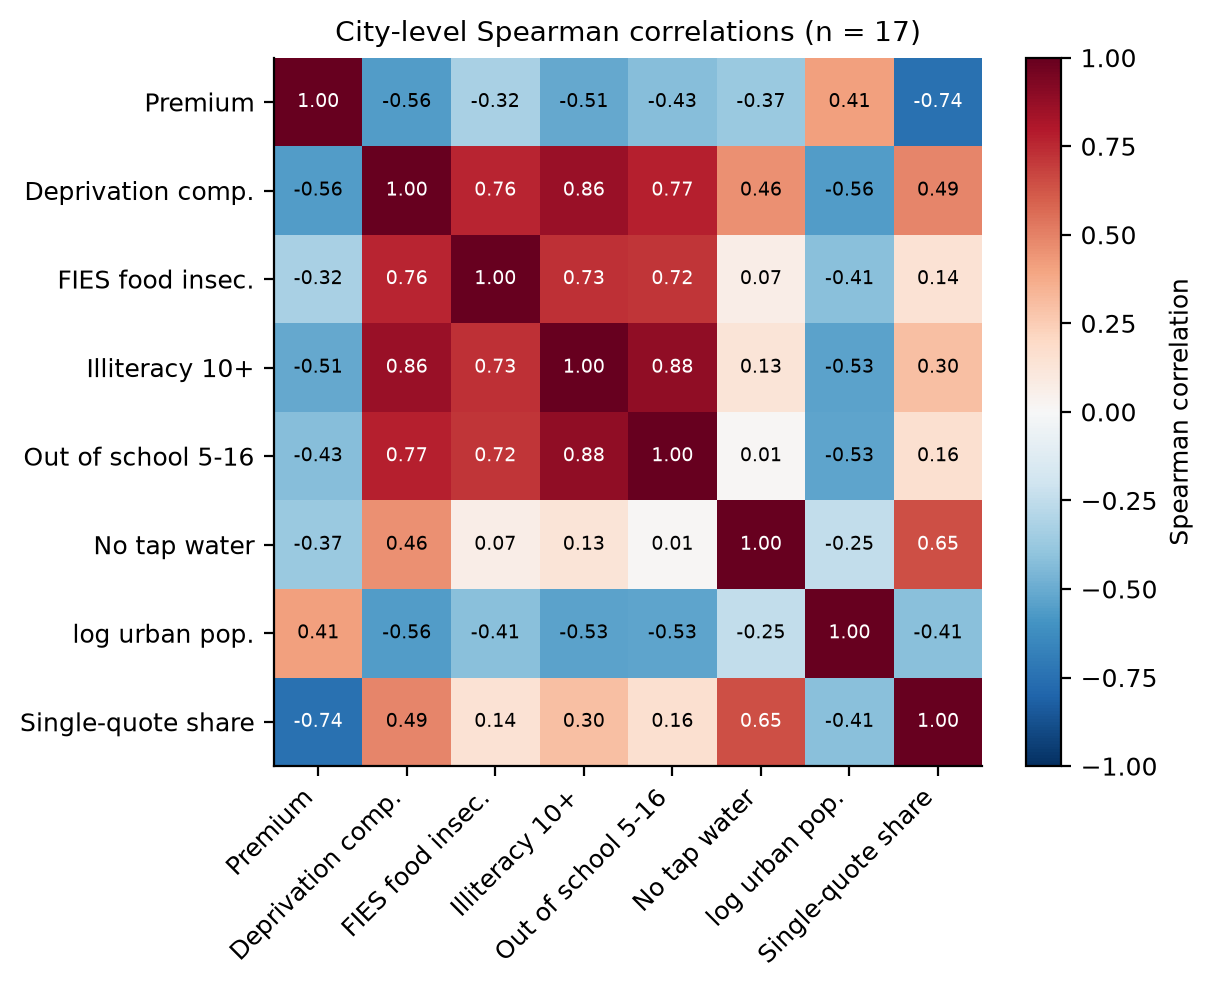

In [28]:
cov, pear, spear = eda.correlations(cityx, m); display(cov.round(4)); display(pear.round(2)); display(spear.round(2)); display(Image(eda.fig_corr(spear)))

### Unit 05: Categorical by categorical (province by premium tercile)

premium_tercile,low,mid,high
province,,,
ICT,0,0,1
Punjab,3,4,1
Sindh,2,1,1
KP,1,0,1
Balochistan,0,0,2


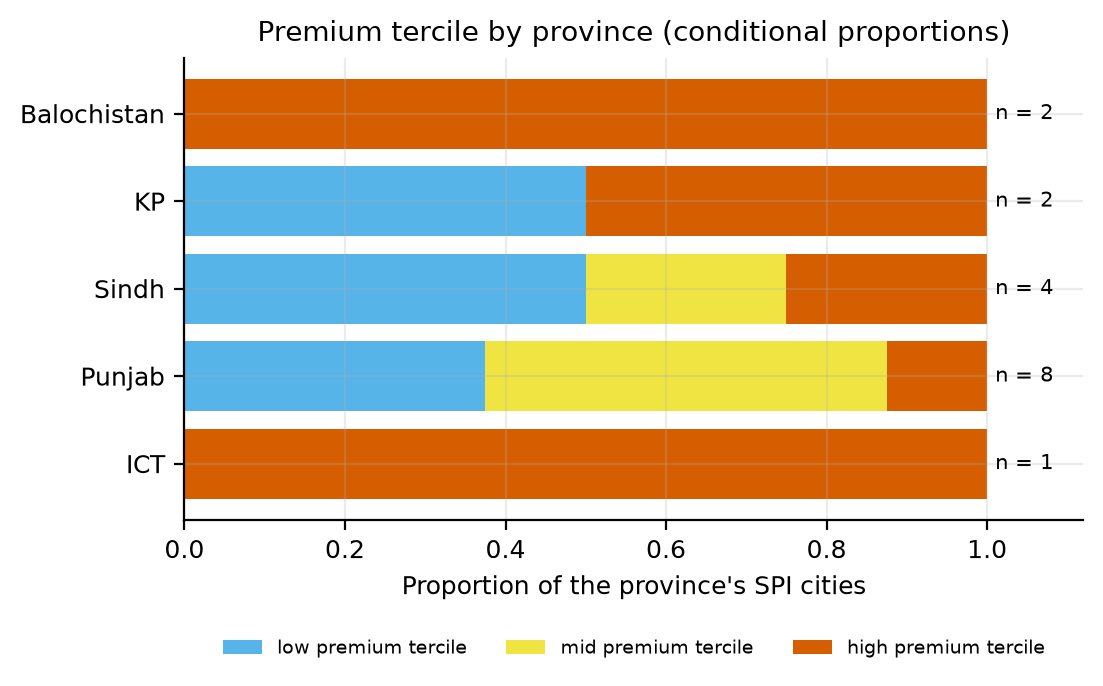

In [29]:
ct = eda.contingency(cityx); display(ct); display(Image(eda.fig_province_tercile(ct)))

### Unit 06: Normal distribution, z-values and the CLT
Pooled relative prices are roughly symmetric but heavy-tailed. Each city's mean premium averages over about 32 items,
which justifies t-based intervals by the CLT. That justification is weaker where a city's item-level means are skewed.

In [30]:
eda.normality(m, prem); {k: eda.N["normal"][k] for k in eda.N["normal"]}

{'rel_price_skew': -0.1443,
 'rel_price_excess_kurtosis': 3.4716,
 'city_item_skew_median': -0.2908,
 'median_within_item_skew_raw': 0.216,
 'median_within_item_skew_log': 0.0236,
 'pooled_raw_price_skew': 2.1284}

### Unit 07: Confidence intervals with sigma unknown
Each observation is one food item's mean relative price for that city, so n is the number of food items (31 or 32),
not the number of rows.

In [31]:
prem[["city", "province", "n_items", "pct_mean", "ci_lo", "ci_hi", "t", "p", "sig_05", "bonferroni_sig"]]

,city,province,n_items,pct_mean,ci_lo,ci_hi,t,p,sig_05,bonferroni_sig
0,Islamabad,ICT,32,14.1415,0.0852,0.1793,5.7338,2.6222e-06,True,True
1,Rawalpindi,Punjab,32,10.2073,0.0583,0.1361,5.1000,1.6126e-05,True,True
2,Karachi,Sindh,32,5.2158,0.0167,0.0850,3.0385,4.7962e-03,True,False
3,Quetta,Balochistan,32,2.8734,-0.0139,0.0706,1.3684,1.8103e-01,False,False
4,Khuzdar,Balochistan,32,1.9236,-0.0214,0.0595,0.9597,3.4463e-01,False,False
5,Peshawar,KP,32,1.6499,-0.0199,0.0526,0.9202,3.6458e-01,False,False
6,Multan,Punjab,32,1.1934,-0.0178,0.0415,0.8167,4.2035e-01,False,False
7,Lahore,Punjab,31,-0.6797,-0.0317,0.0181,-0.5597,5.7981e-01,False,False
8,Gujranwala,Punjab,31,-1.3118,-0.0503,0.0239,-0.7263,4.7329e-01,False,False
9,Faisalabad,Punjab,32,-1.4464,-0.0336,0.0045,-1.5619,1.2847e-01,False,False


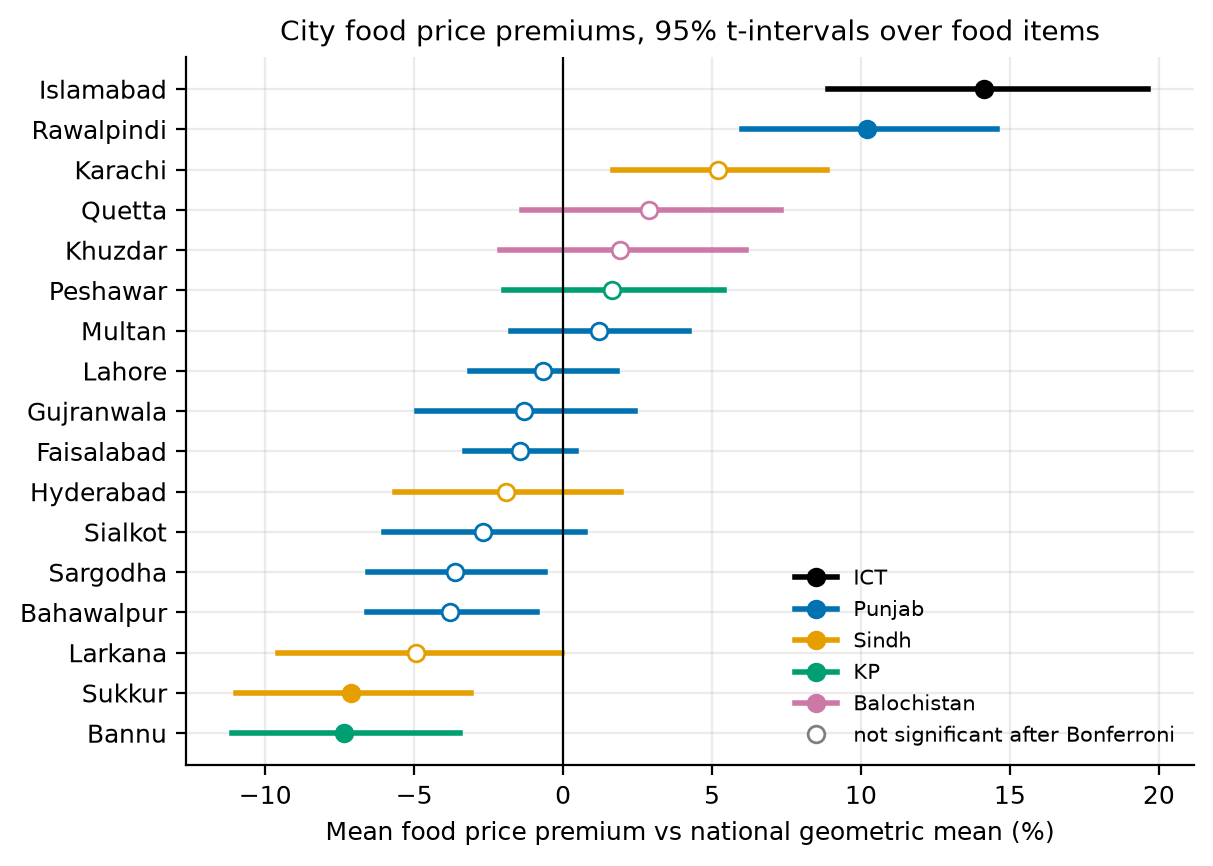

In [32]:
display(Image(eda.fig_city_premiums(prem)))

### Unit 07: Hypothesis tests, Type I and II errors
* **City premiums (two-tailed, 17 tests):** we report the count significant at 0.05 and the count that survives
  Bonferroni at 0.05/17. A Type I error would label a city as paying more when it does not; a Type II error would miss
  a real premium.
* **H2 (one-tailed):** mean cross-city CV, perishables against storables, using the SE(A - B) form. The effective
  sample size is the number of items.
* **Persistence:** each city's rate of staying above the median, tested against 0.5 with n = 17 cities, both for all
  pairs and for pairs where the price changed.

In [33]:
print(json.dumps(eda.N["premium"] | {}, indent=1, default=str)[:600]); eda.h2_test(item)

{
 "n_sig_05": 8,
 "n_sig_bonferroni": 4,
 "bonferroni_alpha": 0.0029,
 "city": {
  "Islamabad": {
   "pct_mean": 14.1415,
   "pct_median": 12.6392,
   "ci_lo_pct": 8.8957,
   "ci_hi_pct": 19.64,
   "p": 0.0,
   "n_items": 32
  },
  "Rawalpindi": {
   "pct_mean": 10.2073,
   "pct_median": 6.7893,
   "ci_lo_pct": 6.0059,
   "ci_hi_pct": 14.5752,
   "p": 0.0,
   "n_items": 32
  },
  "Karachi": {
   "pct_mean": 5.2158,
   "pct_median": 2.6303,
   "ci_lo_pct": 1.6856,
   "ci_hi_pct": 8.8685,
   "p": 0.0048,
   "n_items": 32
  },
  "Quetta": {
   "pct_mean": 2.8734,
   "pct_median": 3.1554,
   "ci_


{'n_perishable': 11,
 'n_storable': 10,
 'mean_cv_perishable': np.float64(0.15654015234589738),
 'mean_cv_storable': np.float64(0.10748625058617367),
 'se_diff': np.float64(0.025607685375042794),
 't_welch': np.float64(1.9155929573990924),
 'p_one_tailed': np.float64(0.03676944599499601),
 'mannwhitney_p_one_tailed': np.float64(0.05655110193358778)}

In [34]:
pc, pres = eda.persistence(m); display(pc); pres

,city,stay_rate,n_pairs,stay_rate_changed,n_pairs_changed
0,Bahawalpur,0.8320,125,0.5185,27
1,Bannu,0.8750,96,0.7632,38
2,Faisalabad,0.9291,141,0.5625,16
3,Gujranwala,0.8911,101,0.8049,41
4,Hyderabad,0.9330,194,0.7955,44
5,Islamabad,0.9593,393,0.9167,108
6,Karachi,0.9646,311,0.9385,130
7,Khuzdar,0.9657,233,0.9500,40
8,Lahore,0.8696,138,0.8222,45
9,Larkana,0.9066,182,0.6500,40


{'overall_stay_rate': np.float64(0.9268889568675436),
 'n_pairs': 3269,
 'overall_stay_rate_changed': np.float64(0.8406113537117904),
 'n_pairs_changed': 916,
 'n_cities': 17,
 'city_rate_min': np.float64(0.8172043010752689),
 'city_rate_max': np.float64(0.9656652360515021),
 't_vs_half': np.float64(36.966487146836585),
 'p_one_tailed': np.float64(3.1761409959417645e-17),
 't_vs_half_changed': np.float64(7.303414354829715),
 'p_one_tailed_changed': np.float64(8.854054801612287e-07),
 'n_cities_changed': 17,
 'city_rate_changed_min': np.float64(0.5185185185185185)}

## Part B. Later-syllabus methods, exploratory only

### Measurement quality and representation (fairness, weeks 8 and 15): exploratory
Measurement quality is the share of food records where MIN = MAX, meaning the city average may rest on a single
quote. Representation compares the 17 SPI cities with each province's urban population (Census 2023).

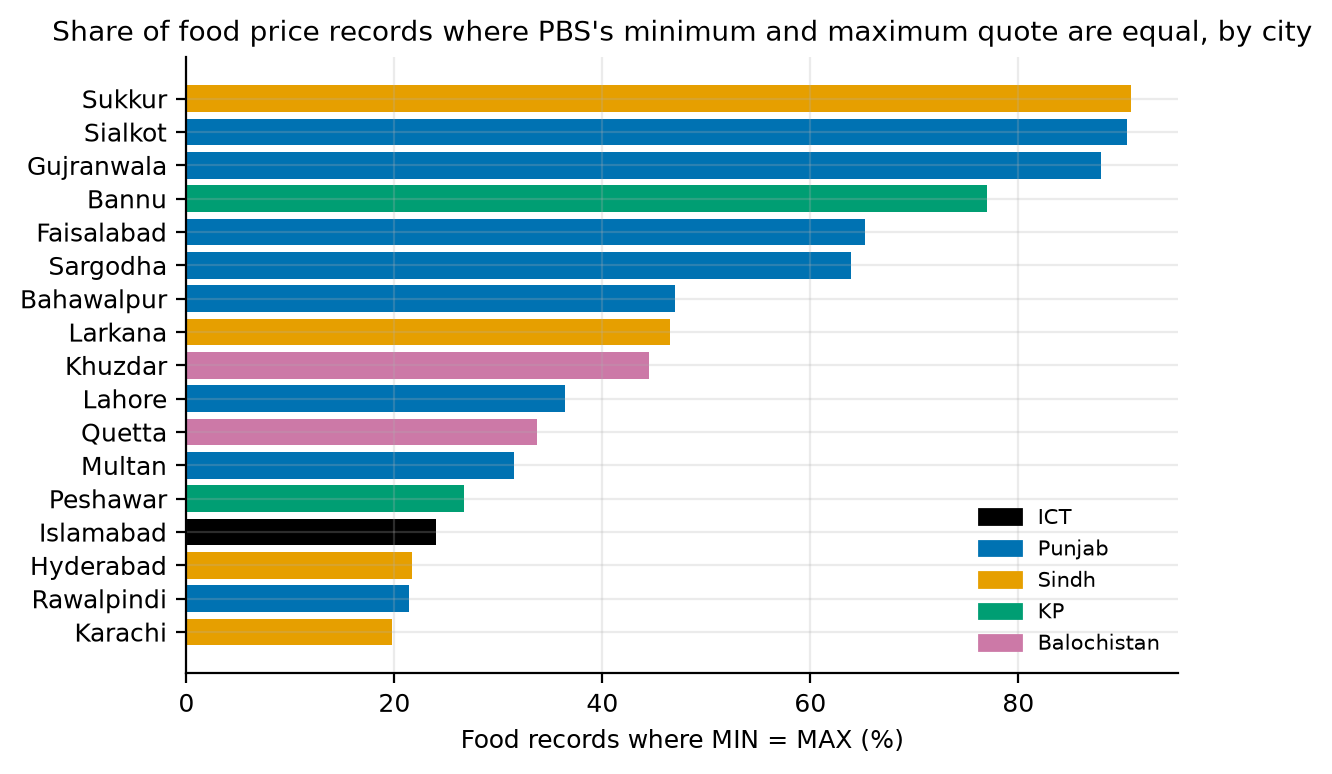

,province,n_cities,spi_pop_urban,province_pop_urban,share_of_province_urban,share_of_national_urban,share_of_spi_cities
0,ICT,1,1.1089e+06,1.1089e+06,1.0000,0.0119,0.0588
1,Punjab,8,3.2413e+07,5.1976e+07,0.6236,0.5601,0.4706
2,Sindh,4,2.2504e+07,2.8965e+07,0.7769,0.3122,0.2353
3,KP,2,1.9544e+06,6.1313e+06,0.3188,0.0661,0.1176
4,Balochistan,2,1.9299e+06,4.6118e+06,0.4185,0.0497,0.1176


In [35]:
q = eda.measurement_quality(m, cityx); display(Image(eda.fig_single_quote(q))); eda.representation(city, parse_census_table1())

### Evaluation metrics (week 6): base rate and unchanged-price share, exploratory

In [36]:
display(eda.unchanged_by_category(m)); {k: eda.N["h3"][k] for k in ["base_rate_contract", "base_rate_refined"]}

,item_category,share_unchanged
0,branded_packaged,0.9221
1,perishable,0.5565
2,prepared_food,0.9843
3,storable_staple,0.7509


{'base_rate_contract': 0.0775, 'base_rate_refined': 0.0289}

### Distance and nearest neighbours (week 7): exploratory

In [37]:
mat = eda.city_item_matrix(m); eda.nearest_neighbours(mat)

,city,nearest,distance,mutual
0,Islamabad,Rawalpindi,2.1076,True
1,Rawalpindi,Islamabad,2.1076,True
2,Gujranwala,Sialkot,4.5306,False
3,Sialkot,Faisalabad,4.3417,False
4,Lahore,Faisalabad,3.9144,True
5,Faisalabad,Lahore,3.9144,True
6,Sargodha,Faisalabad,4.9076,False
7,Multan,Faisalabad,5.1077,False
8,Bahawalpur,Sialkot,5.0075,False
9,Karachi,Hyderabad,5.1119,False


### Hierarchical clustering, Ward linkage (weeks 13 and 14): exploratory

province,Balochistan,ICT,KP,Punjab,Sindh
cluster,,,,,
1,0,1,0,1,0
2,0,0,0,7,0
3,2,0,2,0,4


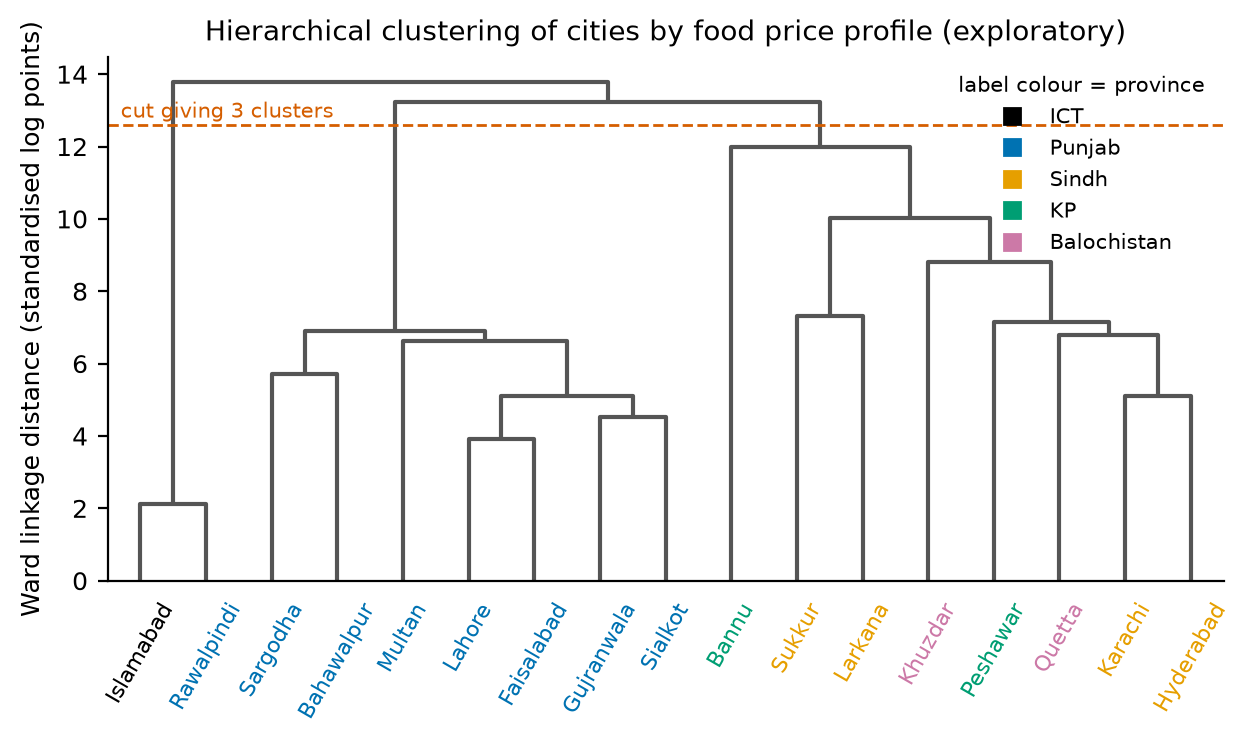

In [38]:
L, clusters = eda.hier_cluster(mat); display(pd.crosstab(clusters.cluster, clusters.province)); display(Image(eda.fig_dendrogram(L, mat)))

### Descriptive regression (week 10): exploratory, coefficients only

In [39]:
coef, simple = eda.regression(m, prem, cityx); display(coef.round(4)); print(eda.N["h1a"]); simple

,city,coef,se,ci_lo,ci_hi,mean
0,Islamabad,0.1324,0.0040,0.1245,0.1403,0.1323
1,Rawalpindi,0.0973,0.0040,0.0894,0.1052,0.0972
2,Gujranwala,-0.0132,0.0041,-0.0212,-0.0052,-0.0132
3,Sialkot,-0.0272,0.0041,-0.0352,-0.0192,-0.0272
4,Lahore,-0.0068,0.0041,-0.0148,0.0012,-0.0068
5,Faisalabad,-0.0145,0.0040,-0.0223,-0.0066,-0.0146
6,Sargodha,-0.0368,0.0040,-0.0446,-0.0289,-0.0369
7,Multan,0.0120,0.0040,0.0041,0.0199,0.0119
8,Bahawalpur,-0.0384,0.0040,-0.0463,-0.0306,-0.0385
9,Karachi,0.0509,0.0040,0.0431,0.0588,0.0508


{'F': 179.2882, 'df1': 16, 'df2': 13727, 'p': 0.0, 'r2_within': 0.1729}


{'slope': np.float64(-0.12653321646688465),
 'slope_ci_lo': np.float64(-0.24904717813405772),
 'slope_ci_hi': np.float64(-0.004019254799711575),
 'intercept': np.float64(0.05391940452782055),
 'r2': np.float64(0.24418215594985174),
 'p': np.float64(0.04378053154287191),
 'n': 17}

### PCA: exploratory

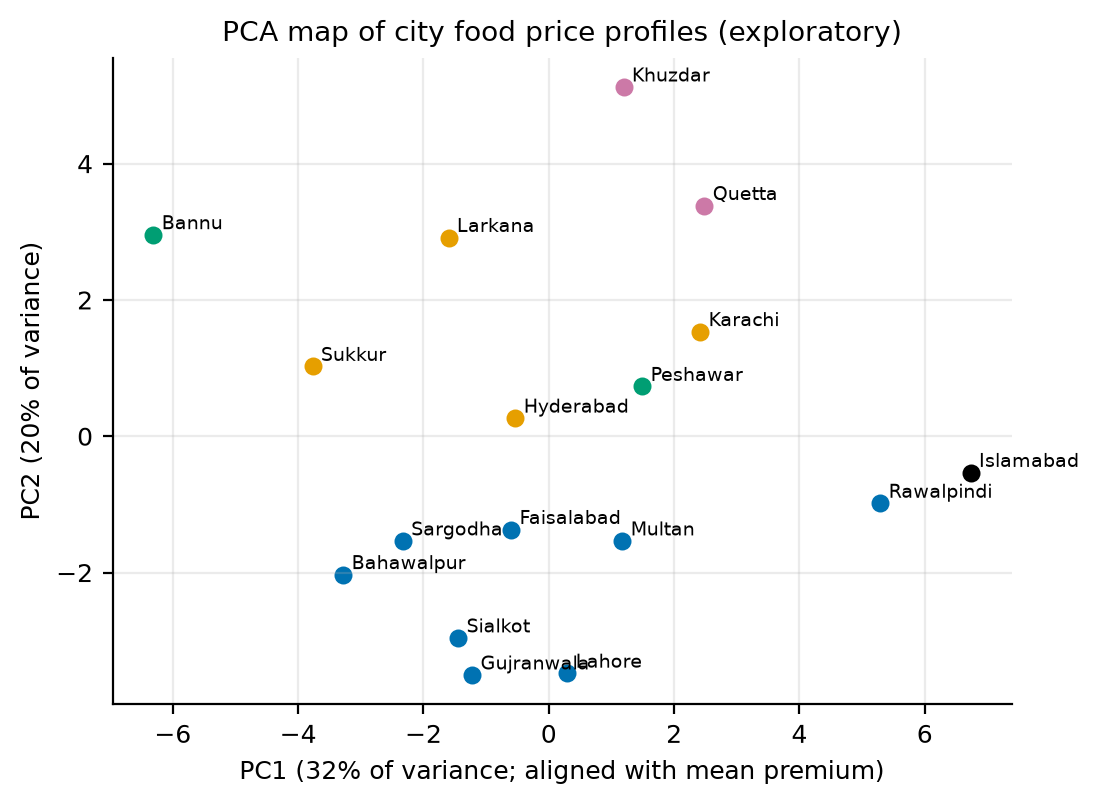

array([0.31770429, 0.19747263, 0.1404974 , 0.06911499, 0.06410136])

In [40]:
p, scores = eda.pca(mat, prem); display(Image(eda.fig_pca(scores, p))); p.explained_variance_ratio_[:5]

### k-means market typology of items (week 13): exploratory

In [41]:
km, km_ct = eda.item_kmeans(item); km_ct

market_type,flexible,intermediate,sticky
item_category,,,
branded_packaged,0,0,7
perishable,2,5,4
prepared_food,0,0,4
storable_staple,0,2,8


### H5 burden re-ranking (descriptive) and the time-ordered split design (week 8)

,city,province,premium,deprivation_composite,fies_mod_sev_pct,rank_premium,rank_deprivation,rank_fies,burden_composite,burden_fies,rank_burden_composite,rank_burden_fies
0,Islamabad,ICT,0.1323,0.1560,7.9300,1,16,17,0.1560,9.0514,5,16
1,Rawalpindi,Punjab,0.0972,0.1957,9.4100,2,15,15,0.1628,10.3705,4,13
9,Karachi,Sindh,0.0508,0.1380,9.6045,3,17,14,0.0842,10.1054,12,14
15,Quetta,Balochistan,0.0283,0.4931,23.4700,4,7,2,0.2475,24.1444,2,2
16,Khuzdar,Balochistan,0.0191,0.9743,29.2600,5,1,1,0.4458,29.8229,1,1
13,Peshawar,KP,0.0164,0.3000,11.2200,6,12,11,0.1334,11.4051,6,11
7,Multan,Punjab,0.0119,0.5102,16.8800,7,6,7,0.2158,17.0814,3,6
4,Lahore,Punjab,-0.0068,0.3441,17.9600,8,10,5,0.1148,17.8379,7,4
2,Gujranwala,Punjab,-0.0132,0.3310,10.5300,9,11,12,0.1003,10.3919,10,12
5,Faisalabad,Punjab,-0.0146,0.3489,8.6700,10,9,16,0.1034,8.5446,9,17


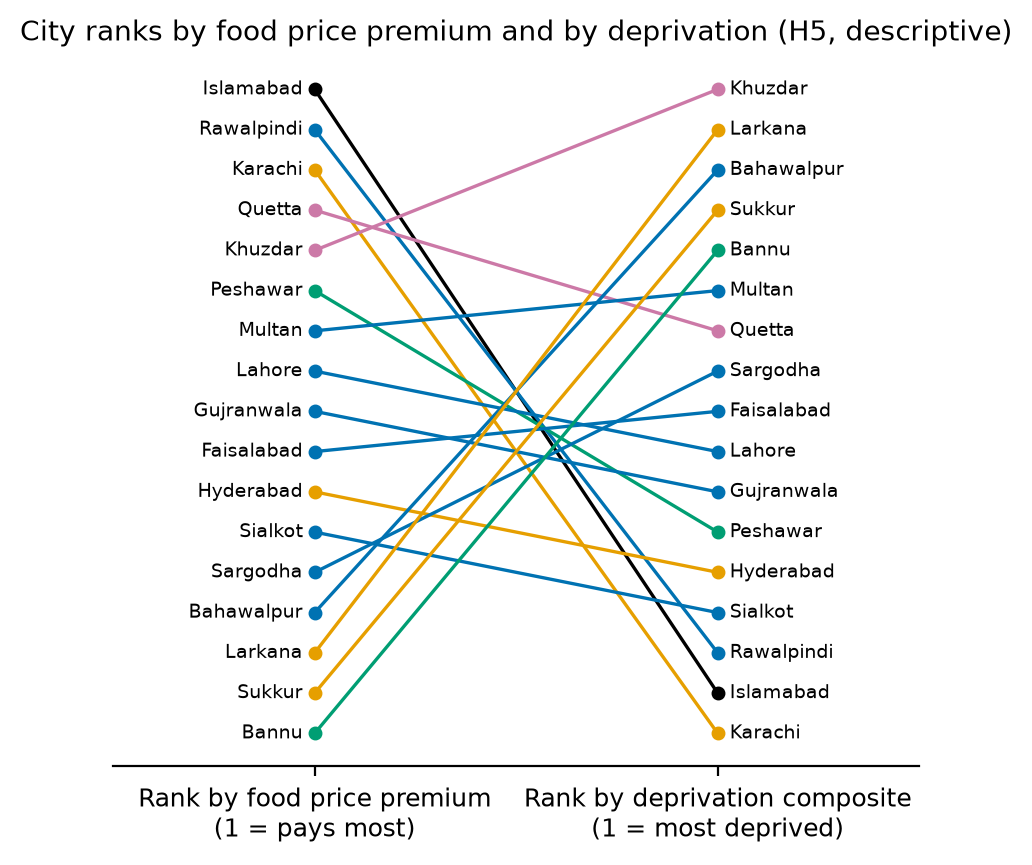

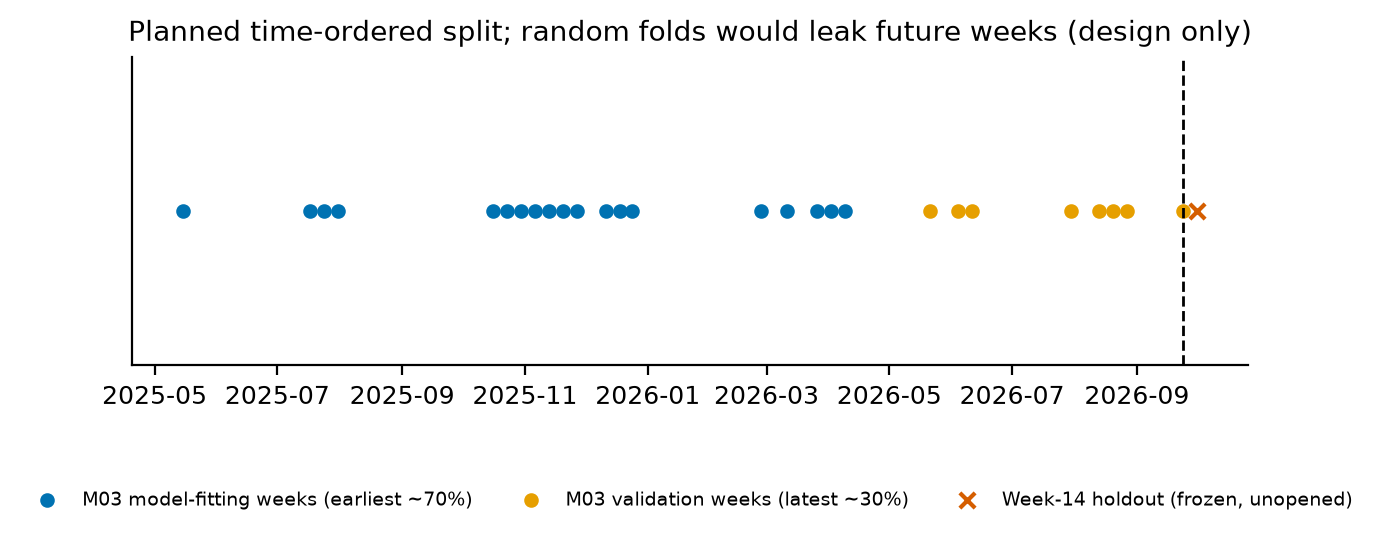

In [42]:
rr = eda.burden_reranking(cityx); display(rr); display(Image(eda.fig_reranking(rr))); display(Image(eda.fig_split_design(o)))

## Save the numbers file used by the manuscript

In [43]:
eda.put("figures.count", len(list((ROOT / "reports/m02/figures").glob("fig*.png"))))
eda.save_numbers()
print("written", sum(1 for _ in json.dumps(eda.N)), "chars to reports/m02/m02_numbers.json")

written 11271 chars to reports/m02/m02_numbers.json
